# Установка основных NLP-библиотек в Kaggle

Для работы с `transformers`, `datasets`, `evaluate`, `accelerate` и `peft` установим зависимости:

```bash
!pip install transformers datasets evaluate accelerate peft
```


In [42]:
!pip install transformers datasets evaluate accelerate peft

# Импорт библиотек

In [67]:
import torch
from transformers import AutoTokenizer, RobertaModel, RobertaTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback, set_seed
from peft import AutoPeftModelForSequenceClassification, LoraConfig, get_peft_model
from datasets import load_dataset
from datasets import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import wandb
from sklearn.model_selection import train_test_split
import evaluate
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay


nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
set_seed(42)
%matplotlib inline


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Загрузка датасета AG News и объединение сплитов

* Загружаем датасет AG News через `datasets`.
* Преобразуем train и test в `pandas.DataFrame`.
* Склеиваем оба сплита в один общий датафрейм.
* Это удобно для первичного анализа и визуализации.

In [44]:
dataset = load_dataset('SetFit/ag_news')
df_1 = dataset['train'].to_pandas()
df_2 = dataset['test'].to_pandas()
df_full = pd.concat([df_1, df_2], ignore_index=True)


In [45]:
df_full.head()

,text,label,label_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [46]:
df_full.shape

(127600, 3)

# Распределение меток в AG News

- Строим график распределения классов через `seaborn.countplot`.
- Используем палитру `Dark2`.
- Подписываем оси и заголовок на русском языке.

/tmp/ipykernel_58/2896103642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_full, palette='Dark2')


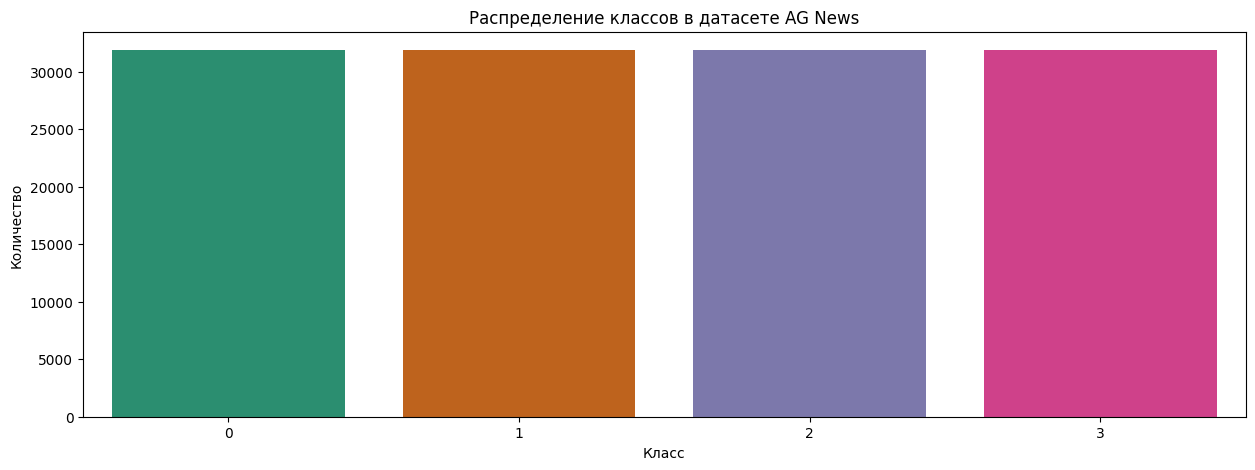

In [47]:
plt.figure(figsize=(15,5))
sns.countplot(x='label', data=df_full, palette='Dark2')  

plt.title('Распределение классов в датасете AG News')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()


# Топ-30 самых частых слов после очистки

1. Переводим весь текст в нижний регистр.
2. Токенизируем текст регулярным выражением.
3. Убираем стоп-слова и одиночные символы.
4. Считаем частоты слов через `Counter`.
5. Выводим 30 самых частых слов на графике.

/tmp/ipykernel_58/1159420205.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=df_words, palette='Set1')


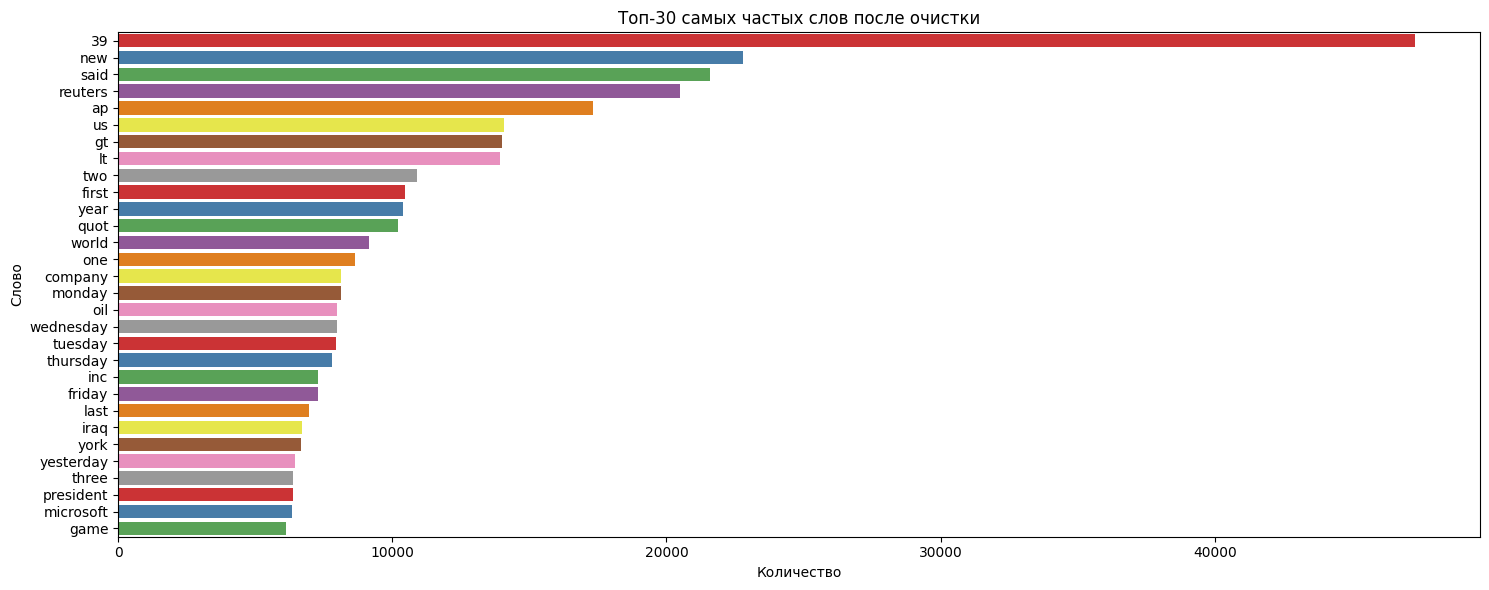

In [48]:
texts = df_full['text'].str.lower()

# Токенизируем, очищаем текст и убираем стоп-слова
def clean_and_tokenize(text):
    words = re.findall(r'\b\w+\b', text)
    return [word for word in words if word not in stop_words and len(word) > 1]

words = texts.apply(clean_and_tokenize)
all_words = [word for sublist in words for word in sublist]

if not all_words:
    raise ValueError('Не удалось извлечь слова для визуализации. Проверьте токенизацию и stop_words.')

# Считаем частоты слов
word_counts = Counter(all_words)
most_common_30 = word_counts.most_common(30)

# Собираем данные для графика
df_words = pd.DataFrame(most_common_30, columns=['word', 'count'])

# Строим график
plt.figure(figsize=(15, 6))
sns.barplot(x='count', y='word', data=df_words, palette='Set1')
plt.title('Топ-30 самых частых слов после очистки')
plt.xlabel('Количество')
plt.ylabel('Слово')
plt.tight_layout()
plt.show()


# Облако слов по самым частым токенам

- Склеиваем очищенные слова в одну строку.
- Строим `WordCloud` с чёрным фоном.
- Визуализируем результат в крупном размере для лучшей читаемости.

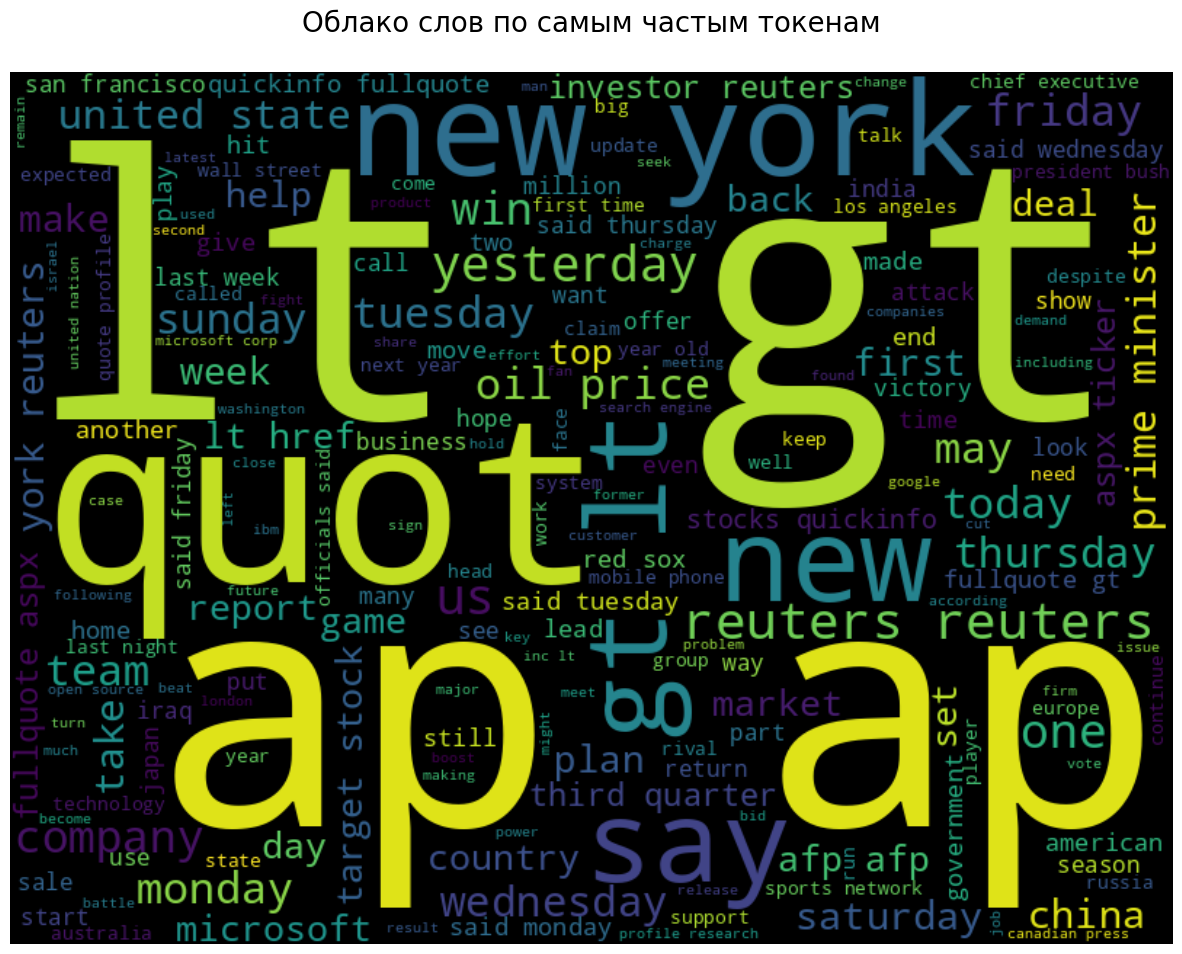

In [49]:
text_for_wordcloud = ' '.join(all_words)

if not text_for_wordcloud.strip():
    raise ValueError('Список слов пустой, облако слов построить нельзя. Сначала проверьте ячейку с токенизацией.')

# Создаём объект облака слов
wordcloud = WordCloud(width=800, height=600, background_color='black').generate(text_for_wordcloud)

# Отрисовываем результат
plt.figure(figsize=(15,15))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов по самым частым токенам\n', fontsize=20)
plt.show()


# Предобработка датасета с токенизатором RoBERTa

- Используем базовую модель `roberta-base`.
- Токенизируем текст без статического паддинга.
- Ограничиваем длину последовательности, а паддинг делаем динамически через `DataCollatorWithPadding`.
- Это обычно даёт более стабильное и быстрое обучение.

In [50]:
MAX_LENGTH = 128

base_model = 'roberta-base'
tokenizer = RobertaTokenizer.from_pretrained(base_model)

# Токенизируем без статического паддинга, чтобы паддинг делал collator
def preprocess(examples):
    return tokenizer(examples['text'], truncation=True, max_length=MAX_LENGTH)

# Применяем предобработку ко всему датасету
tokenized_dataset = dataset.map(preprocess, batched=True, remove_columns=['text'])


# Подготовка датасета и модели

- Берём ограниченную, но достаточно большую подвыборку из train для обучения.
- Делаем отдельный validation-split из train и не трогаем официальный test до финальной оценки.
- Получаем список классов и создаём `id2label` / `label2id`.
- Инициализируем модель классификации поверх `roberta-base`.

In [51]:
def get_class_names(dataset):
    """
    SetFit/ag_news может хранить label как Value, а названия классов — в label_text.
    Сначала пытаемся взять names из feature-описания, затем label_text, и только потом числовые метки.
    """

    label_feature = dataset["train"].features["label"]

    if hasattr(label_feature, "names") and label_feature.names:
        return label_feature.names

    train_df = dataset["train"].to_pandas()

    if "label_text" in train_df.columns:
        label_map = (
            train_df[["label", "label_text"]]
            .drop_duplicates()
            .sort_values("label")
        )
        return label_map["label_text"].tolist()

    labels = sorted(train_df["label"].unique().tolist())
    return [str(label) for label in labels]


In [72]:
MAX_TRAIN_SAMPLES = 30000
FINAL_TEST_SAMPLES = 2000
# Берём подвыборку из train и делаем стратифицированный split через pandas,
# потому что в SetFit/ag_news колонка label имеет тип Value, а не ClassLabel.
train_subset = tokenized_dataset['train'].shuffle(seed=42).select(range(MAX_TRAIN_SAMPLES))
train_df = train_subset.to_pandas()

train_df_split, eval_df_split = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df['label'],
)

train_dataset = Dataset.from_pandas(train_df_split.reset_index(drop=True), preserve_index=False)
eval_dataset = Dataset.from_pandas(eval_df_split.reset_index(drop=True), preserve_index=False)
test_df = tokenized_dataset['test'].to_pandas()
final_test_size = min(FINAL_TEST_SAMPLES, len(test_df))
final_test_df, _ = train_test_split(
    test_df,
    train_size=final_test_size,
    random_state=42,
    stratify=test_df['label'],
)
final_test_dataset = Dataset.from_pandas(final_test_df.reset_index(drop=True), preserve_index=False)

test_dataset = final_test_dataset

for column in ['label_text']:
    if column in train_dataset.column_names:
        train_dataset = train_dataset.remove_columns(column)
    if column in eval_dataset.column_names:
        eval_dataset = eval_dataset.remove_columns(column)
    if column in test_dataset.column_names:
        test_dataset = test_dataset.remove_columns(column)

class_names = get_class_names(dataset)
num_labels = len(class_names)
id2label = {i: label for i, label in enumerate(class_names)}
label2id = {label: i for i, label in enumerate(class_names)}
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors='pt')

my_basemodel = AutoModelForSequenceClassification.from_pretrained(
    base_model,
    id2label=id2label,
    num_labels=num_labels,
    label2id=label2id,
)
print(f'Train size: {len(train_dataset)}')
print(f'Eval size: {len(eval_dataset)}')
print(f'Test size: {len(test_dataset)}')
print(f'Number of labels: {num_labels}')
print(f'The labels: {class_names}')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train size: 27000
Eval size: 3000
Test size: 2000
Number of labels: 4
The labels: ['World', 'Sports', 'Business', 'Sci/Tech']


# Метрика accuracy для оценки модели

- Загружаем метрику `accuracy` из библиотеки `evaluate`.
- В `compute_metrics` переводим logits в номера классов через `argmax`.
- Возвращаем accuracy в формате, который ожидает `Trainer`.

In [53]:
import evaluate
import numpy as np

accuracy = evaluate.load('accuracy')

# Переводим logits в метки классов и считаем accuracy
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)


# Параметры обучения для полного fine-tuning

- Увеличиваем число эпох и используем более аккуратный learning rate.
- Добавляем `weight_decay`, `warmup_ratio` и сохранение лучшей модели.
- Оцениваем модель по `eval_accuracy`, а не по loss.

In [54]:
full_training_args = TrainingArguments(
    output_dir='./results/full_finetune',
    eval_strategy='steps',
    eval_steps=1000,
    save_strategy='steps',
    save_steps=1000,
    save_total_limit=2,
    learning_rate=2e-5,
    lr_scheduler_type='linear',
    warmup_ratio=0.06,
    weight_decay=0.01,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir='./logs/full_finetune',
    logging_steps=100,
    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_accuracy',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    seed=42,
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# Инициализация Trainer для полного обучения

- Передаём модель, датасеты, collator и метрики в `Trainer`.
- Добавляем `label_names`, чтобы метрики корректно считались и в новых версиях `transformers`.
- Включаем `EarlyStoppingCallback`, чтобы не переобучать модель без смысла.

In [55]:
trainer = Trainer(
    model=my_basemodel,
    args=full_training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


# Запуск обучения

- Запускаем обучение полной модели.
- Лучшая версия на валидации будет восстановлена автоматически.

In [56]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Accuracy
1000,0.348848,0.392714,0.939667
2000,0.237562,0.405849,0.943000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2532, training_loss=0.4483415824353789, metrics={'train_runtime': 1074.872, 'train_samples_per_second': 75.358, 'train_steps_per_second': 2.356, 'total_flos': 4393252402631040.0, 'train_loss': 0.4483415824353789, 'epoch': 3.0})

In [57]:
trainer.save_model('full_finetune_model')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# Обучение LoRA

# Настройка LoRA через PEFT

- Подключаем LoRA к RoBERTa для параметро-эффективного обучения.
- Сохраняем классификационную голову вместе с адаптерами.
- Для LoRA используем отдельные training arguments и отдельный `Trainer`.

In [58]:
my_basemodel = AutoModelForSequenceClassification.from_pretrained(
    base_model,
    id2label=id2label,
    num_labels=num_labels,
    label2id=label2id,
)

# Настраиваем LoRA так, чтобы адаптеры и голова классификации сохранялись отдельно
peft_config = LoraConfig(
    task_type='SEQ_CLS',
    inference_mode=False,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=['query', 'value'],
    modules_to_save=['classifier'],
)

peft_model = get_peft_model(my_basemodel, peft_config)

lora_training_args = TrainingArguments(
    output_dir='./results/lora',
    eval_strategy='steps',
    eval_steps=1000,
    save_strategy='steps',
    save_steps=1000,
    save_total_limit=2,
    learning_rate=2e-4,
    lr_scheduler_type='linear',
    warmup_ratio=0.05,
    weight_decay=0.0,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir='./logs/lora',
    logging_steps=100,
    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_accuracy',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    seed=42,
)

def get_trainer(model, args):
    return Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        processing_class=tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

print('PEFT модель')
peft_model.print_trainable_parameters()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated 

PEFT модель
trainable params: 1,183,492 || all params: 125,832,200 || trainable%: 0.9405


# Обучение LoRA-модели

- Создаём `Trainer` для LoRA-модели.
- Обучаем только адаптеры и classification head.

In [59]:
# Обучаем LoRA-модель
peft_lora_finetuning_trainer = get_trainer(peft_model, lora_training_args)
peft_lora_finetuning_trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Accuracy
1000,0.431342,0.409074,0.932333
2000,0.358272,0.395198,0.937000


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=2532, training_loss=0.5239260513070635, metrics={'train_runtime': 852.6116, 'train_samples_per_second': 95.002, 'train_steps_per_second': 2.97, 'total_flos': 4453957589164800.0, 'train_loss': 0.5239260513070635, 'epoch': 3.0})

# Сохранение LoRA-модели и токенизатора

- Сохраняем обученную LoRA-модель в отдельную папку.
- Сохраняем токенизатор рядом с моделью.

In [60]:
peft_lora_finetuning_trainer.save_model('lora-finetuned-model')
tokenizer.save_pretrained('lora-finetuned-model')


('lora-finetuned-model/tokenizer_config.json',
 'lora-finetuned-model/tokenizer.json')

# Загрузка обученной модели и функция классификации

- Загружаем LoRA-модель через PEFT-aware loader.
- Функция `classify` берёт текст, токенизирует его и возвращает предсказанный класс.

In [62]:
inference_model = AutoPeftModelForSequenceClassification.from_pretrained(
    '/kaggle/working/lora-finetuned-model',
    id2label=id2label,
    label2id=label2id,
)

def classify(text):
    # Токенизируем текст и переводим вход в PyTorch tensors
    inputs = tokenizer(text, truncation=True, padding=True, return_tensors='pt')
    # Делаем прямой проход через модель
    output = inference_model(**inputs)

    # Берём класс с максимальным логитом
    prediction = output.logits.argmax(dim=-1).item()

    print(f'Class: {prediction}, Label: {id2label[prediction]}, Text: {text}')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Пример использования функции классификации

- Проверяем модель на двух коротких примерах.
- Это быстрый sanity check перед финальной оценкой.

In [64]:
classify('Kederis proclaims innocence Olympic champion Kostas Kederis today left hospital ahead of his date with IOC inquisitors claiming his ...')
classify("Wall St. Bears Claw Back Into the Black Reuters - Short-sellers, Wall Street's dwindling band of ultra-cynics, are seeing green again.")


Class: 1, Label: Sports, Text: Kederis proclaims innocence Olympic champion Kostas Kederis today left hospital ahead of his date with IOC inquisitors claiming his ...
Class: 2, Label: Business, Text: Wall St. Bears Claw Back Into the Black Reuters - Short-sellers, Wall Street's dwindling band of ultra-cynics, are seeing green again.


# Функция оценки модели через DataLoader и accuracy

- Собираем `DataLoader` для батчевой оценки.
- Прогоняем модель в режиме `eval` без градиентов.
- Накапливаем предсказания и считаем итоговую accuracy.

In [65]:
from torch.utils.data import DataLoader
from IPython.display import display
import pandas as pd
from tqdm import tqdm

# Финальная оценка считает accuracy, precision, recall и F1 macro по всему набору.
def evaluate_model(inference_model, dataset, model_name='model', show_confusion_matrix=False):
    eval_dataloader = DataLoader(
        dataset.rename_column('label', 'labels'),
        batch_size=8,
        collate_fn=data_collator,
    )
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    inference_model.to(device)
    inference_model.eval()

    all_predictions = []
    all_labels = []

    for step, batch in enumerate(tqdm(eval_dataloader)):
        batch.to(device)
        with torch.no_grad():
            outputs = inference_model(**batch)
        predictions = outputs.logits.argmax(dim=-1)
        all_predictions.extend(predictions.detach().cpu().numpy().tolist())
        all_labels.extend(batch['labels'].detach().cpu().numpy().tolist())

    acc = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average='macro',
        zero_division=0,
    )
    cm = confusion_matrix(all_labels, all_predictions, labels=list(range(len(class_names))))

    metrics_df = pd.DataFrame([
        {
            'model': model_name,
            'accuracy': acc,
            'precision_macro': precision,
            'recall_macro': recall,
            'f1_macro': f1,
        }
    ])

    if show_confusion_matrix:
        fig, ax = plt.subplots(figsize=(8, 7))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
        ax.set_title(f'Confusion matrix: {model_name}')
        plt.tight_layout()
        plt.show()

    return metrics_df, cm


In [73]:
# Evaluate the non fine-tuned model
base_metrics, base_cm = evaluate_model(
    AutoModelForSequenceClassification.from_pretrained(base_model, id2label=id2label, num_labels=num_labels, label2id=label2id),
    test_dataset,
    model_name='base_model',
)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 250/250 [00:11<00:00, 20.91it/s]


In [74]:
# Evaluate the PEFT fine-tuned model
lora_metrics, lora_cm = evaluate_model(inference_model, test_dataset, model_name='lora_peft')


100%|██████████| 250/250 [00:12<00:00, 20.21it/s]


In [75]:
# Evaluate the Fully fine-tuned model
full_metrics, full_cm = evaluate_model(
    AutoModelForSequenceClassification.from_pretrained('/kaggle/working/full_finetune_model', id2label=id2label, num_labels=num_labels, label2id=label2id),
    test_dataset,
    model_name='full_finetune',
)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 250/250 [00:10<00:00, 23.93it/s]


,model,accuracy,precision_macro,recall_macro,f1_macro
0,base_model,0.2525,0.201671,0.2525,0.105273
1,lora_peft,0.9260,0.925965,0.9260,0.925967
2,full_finetune,0.9365,0.936628,0.9365,0.936515


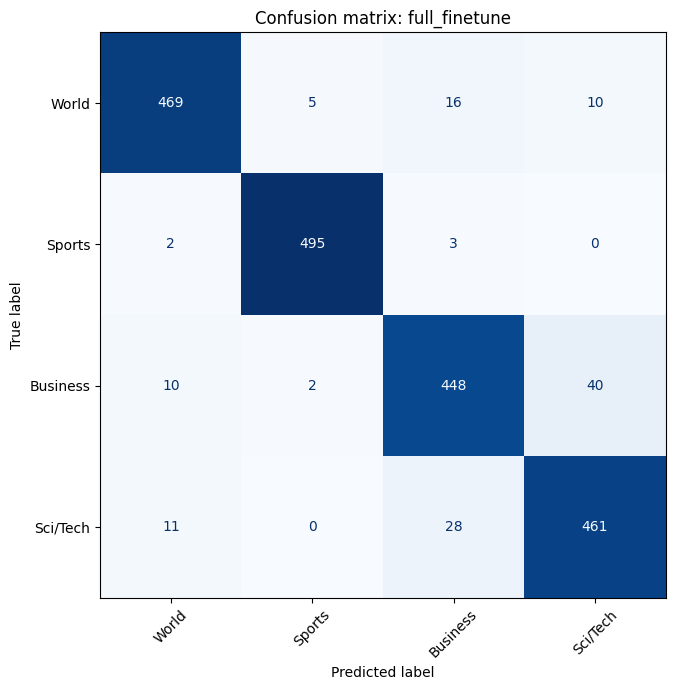

In [76]:
# Итоговая таблица сравнения моделей на финальном стратифицированном тесте
summary_df = pd.concat([base_metrics, lora_metrics, full_metrics], ignore_index=True)
display(summary_df)

# Конфьюжн-матрица для лучшей финальной модели
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=full_cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('Confusion matrix: full_finetune')
plt.tight_layout()
plt.show()
